In [2]:
import torch
import numpy as np
print ("PyTorch版本:",torch.__version__)


PyTorch版本: 2.11.0+cu128


In [3]:
t1=torch.tensor([[1,2,3],
                 [4,5,6]])
print("创建的张量: \n",t1)
print("张量形状: ",t1.shape)
print("张量数据类型: ",t1.dtype)


创建的张量: 
 tensor([[1, 2, 3],
        [4, 5, 6]])
张量形状:  torch.Size([2, 3])
张量数据类型:  torch.int64


In [4]:
#numpy数组和张量互转
np_arr=np.array([[255,0,0],
                 [0,255,0]])
t_from_np=torch.from_numpy(np_arr)
print("Numpy数组：\n", np_arr)
print("转成的张量：\n", t_from_np)
print(np_arr.dtype)

Numpy数组：
 [[255   0   0]
 [  0 255   0]]
转成的张量：
 tensor([[255,   0,   0],
        [  0, 255,   0]])
int64


In [5]:
print("取第一行：",t1[0])
print("所有元素+10：\n",t1+10)
print("所有元素*2：\n",t1*2)

取第一行： tensor([1, 2, 3])
所有元素+10：
 tensor([[11, 12, 13],
        [14, 15, 16]])
所有元素*2：
 tensor([[ 2,  4,  6],
        [ 8, 10, 12]])


In [6]:
device="cuda" if torch.cuda.is_available() else "cpu"
print("当前使用的设备：",device)
t1=t1.to(device)
print("张量现在所在设备：",t1.device)

当前使用的设备： cuda
张量现在所在设备： cuda:0


In [7]:
#课后训练：
np_arr_homework=np.array([[[1,2,3],[1,2,3],[1,3,2]],
                          [[1,2,3],[3,2,1],[3,2,1]],
                          [[3,2,1],[2,3,1],[4,7,8]]])
t1_homework=torch.from_numpy(np_arr_homework)
print(t1_homework.shape)
print(t1_homework+5)
device_homework='cuda' if torch.cuda.is_available() else 'cpu'
print("当前使用的设备是：",device_homework)
t1_homework=t1_homework.to(device_homework)

torch.Size([3, 3, 3])
tensor([[[ 6,  7,  8],
         [ 6,  7,  8],
         [ 6,  8,  7]],

        [[ 6,  7,  8],
         [ 8,  7,  6],
         [ 8,  7,  6]],

        [[ 8,  7,  6],
         [ 7,  8,  6],
         [ 9, 12, 13]]])
当前使用的设备是： cuda


In [8]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
plt.rcParams["font.family"]=['SimHei']
plt.rcParams["axes.unicode_minus"]=False

device ="cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE=224 if device=="cuda" else 128
BATCH_SIZE=32

In [9]:
data_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [10]:
full_dataset = datasets.ImageFolder(
    root="./corn_disease",
    transform=data_transform
)
print("自动识别到的3个类别：",full_dataset.classes)
print("总图片数量:",len(full_dataset))

img, label = full_dataset[0]
print("单张图shape：", img.shape)
print("对应标签：", label)


自动识别到的3个类别： ['Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy']
总图片数量: 3339
单张图shape： torch.Size([3, 224, 224])
对应标签： 0


In [11]:
# 【核心操作：80%训练，20%验证】
train_size=int(0.8*len(full_dataset))
val_size=len(full_dataset)-train_size
train_dataset,val_dataset=random_split(full_dataset,[train_size,val_size])

print(f"训练集图片数：{train_size},验证集图片数：{val_size}")

训练集图片数：2671,验证集图片数：668


In [12]:
# 【核心操作：训练集打乱，验证集不打乱】
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [13]:
for images,labels in train_loader:
    print("一批图片的数量shape:",images.shape)
    print("对应标签的shape:",labels.shape)
    print("标签取值（0/1/2对应三类）：",labels[:10])
    break

一批图片的数量shape: torch.Size([32, 3, 224, 224])
对应标签的shape: torch.Size([32])
标签取值（0/1/2对应三类）： tensor([1, 2, 1, 2, 0, 0, 0, 2, 2, 1])


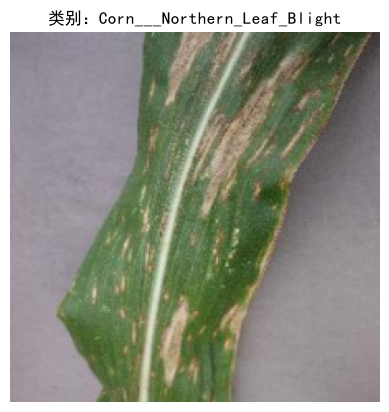

In [14]:
img=images[0].permute(1,2,0).numpy()             #把通道维度移回最后
img=img*[0.229,0.224,0.225]+[0.485,0.456,0.406]  #反标准化
plt.imshow(img)
plt.title(f"类别：{full_dataset.classes[labels[0]]}")
plt.axis('off')
plt.show()

In [15]:
# 【固定模板：搭模型通用，直接复用】
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 自动识别设备，和之前数据管道的配置一致
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224 if device == "cuda" else 128
BATCH_SIZE = 32
print(device)

cuda


In [16]:
class SimpleCornCNN(nn.Module):
    def __init__(self,num_classes=3):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,padding=1)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(2)

        self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(2)

        self.flatten=nn.Flatten()
        fc_input_size=32*(IMG_SIZE//4)*(IMG_SIZE//4)
        self.fc=nn.Linear(fc_input_size,num_classes)

    def forward(self,x):
        x=self.pool1(self.relu1(self.conv1(x)))
        x=self.pool2(self.relu2(self.conv2(x)))
        x=self.flatten(x)
        x=self.fc(x)
        return x

In [17]:
model=SimpleCornCNN(num_classes=3).to(device)
print(model)

SimpleCornCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=100352, out_features=3, bias=True)
)


In [18]:
# 先复用你之前写好的数据管道，取一批图
# （如果你已经跑过数据管道，直接用之前的train_loader即可，不用重复写）
data_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(root="./corn_disease", transform=data_transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 取一批图片
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    print("输入图片shape：", images.shape)

    # 【核心：图片喂给模型，得到分类输出】
    outputs = model(images)
    print("模型输出shape：", outputs.shape)
    print("前3张图的分类分数：\n", outputs[:3])
    break


输入图片shape： torch.Size([32, 3, 224, 224])
模型输出shape： torch.Size([32, 3])
前3张图的分类分数：
 tensor([[-0.0884, -0.0833, -0.0135],
        [-0.0183,  0.0665, -0.0280],
        [-0.1575,  0.1770,  0.0707]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [19]:
# 【核心：多分类专用损失函数】
criterion = nn.CrossEntropyLoss()
# 计算这批图的初始损失（模型随机初始化，和瞎猜差不多）
loss = criterion(outputs, labels)
print("初始损失值：", loss.item())


初始损失值： 1.1507091522216797


In [35]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split

device='cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE=224 if device=='cuda' else 128
BATCH_SIZE=32
print("使用的设备为：",device)

class SimpleCornCnn(nn.Module):
    def __init__(self,num_classes=3):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,padding=1)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(2)

        self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(2)

        self.flatten=nn.Flatten()
        fc_input_size=32*(IMG_SIZE//4)*(IMG_SIZE//4)
        self.fc=nn.Linear(fc_input_size,num_classes)

    def forward(self,x):
        x=self.pool1(self.relu1(self.conv1(x)))
        x=self.pool2(self.relu2(self.conv2(x)))
        x=self.flatten(x)
        x=self.fc(x)
        return x

model=SimpleCornCnn(num_classes=3).to(device)
print(model)

data_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
full_dataset=datasets.ImageFolder(
    root='./corn_disease',
    transform=data_transform
)
train_size=int(0.8*len(full_dataset))
val_size=len(full_dataset)-train_size
train_dataset,val_dataset=random_split(full_dataset,[train_size,val_size])
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    print("输入图片shape：",images.shape)
    outputs=model(images)
    print("模型输出shape:",outputs.shape)
    print("前三张图的分类分数:",outputs[:3])
    break

criterion=nn.CrossEntropyLoss()
loss=criterion(outputs,labels)
print("初始损失值：",loss.item())

使用的设备为： cuda
SimpleCornCnn(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=100352, out_features=3, bias=True)
)
输入图片shape： torch.Size([32, 3, 224, 224])
模型输出shape: torch.Size([32, 3])
前三张图的分类分数: tensor([[-0.0049,  0.0379,  0.1170],
        [ 0.0211,  0.0872, -0.1328],
        [ 0.0159, -0.0281,  0.0038]], device='cuda:0',
       grad_fn=<SliceBackward0>)
初始损失值： 1.0975944995880127


In [36]:
#训练集流水线，加入数据增强
train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    #随机进行水平旋转，概率为0.5
    transforms.RandomHorizontalFlip(p=0.5),
    #随机进行旋转±15°
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

#验证集流水线，验证集不增强，只用基础预处理，保证结果公平
val_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])



In [37]:
#不指定transform以进行加载完整数据集
full_dataset=datasets.ImageFolder(root="./corn_disease")

train_size=int(0.8*len(full_dataset))
val_size=len(full_dataset)-train_size
train_idx,val_idx=random_split(full_dataset,[train_size,val_size])

#给两个数据集分别绑定对应的transform
train_dataset=datasets.ImageFolder(root="./corn_disease",transform=train_transform)
val_dataset=datasets.ImageFolder(root="./corn_disease",transform=val_transform)

#按之前切好的索引取子集
train_dataset=torch.utils.data.Subset(train_dataset,train_idx.indices)
val_dataset=torch.utils.data.Subset(val_dataset,val_idx.indices)

#创建DataLoader
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)


In [38]:
#定义优化器和训练参数
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()
EPOCHS=10

In [39]:
#训练循环
history={
    "train_loss":[],
    "train_acc":[],
    "val_loss":[],
    "val_acc":[]
}
for epoch in range(EPOCHS):
    #切换训练模式
    model.train()
    train_loss=0.0
    train_correct=0
    train_total=0

    #遍历训练集批次
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)

        #训练的三步骤
        optimizer.zero_grad()   #清空上一轮梯度
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()   #反向传播算梯度
        optimizer.step()  #更新参数

        #统计指标
        train_loss+=loss.item()
        _,predicted=torch.max(outputs.data,1)
        train_total +=labels.size(0)
        train_correct+=(predicted == labels).sum().item()

    #计算一轮平均损失和准确率
    avg_train_loss=train_loss/len(train_loader)
    avg_train_acc=100*train_correct/train_total

    #验证阶段
    model.eval()
    val_loss=0.0
    val_correct=0
    val_total=0

    #验证时不更新梯度
    with torch.no_grad():
        for images,labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion(outputs,labels)

            val_loss+=loss.item()
            _,predicted=torch.max(outputs.data,1)
            val_total+=labels.size(0)
            val_correct+=(predicted==labels).sum().item()

    avg_val_loss=val_loss/len(val_loader)
    avg_val_acc=100*val_correct/val_total

    #存入历史记录
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(avg_val_acc)

    print(f"第{epoch+1}轮 | 训练损失:{avg_train_loss:.3f} 训练准确率：{avg_train_acc:.1f}% | 验证损失：{avg_val_loss:.3f} 验证准确率：{avg_val_acc:.1f}%")


第1轮 | 训练损失:0.510 训练准确率：92.2% | 验证损失：0.028 验证准确率：99.3%
第2轮 | 训练损失:0.036 训练准确率：98.9% | 验证损失：0.016 验证准确率：99.7%
第3轮 | 训练损失:0.021 训练准确率：99.3% | 验证损失：0.019 验证准确率：99.4%
第4轮 | 训练损失:0.026 训练准确率：99.2% | 验证损失：0.025 验证准确率：99.4%
第5轮 | 训练损失:0.015 训练准确率：99.6% | 验证损失：0.012 验证准确率：99.7%
第6轮 | 训练损失:0.027 训练准确率：99.1% | 验证损失：0.025 验证准确率：99.1%
第7轮 | 训练损失:0.007 训练准确率：99.7% | 验证损失：0.022 验证准确率：99.6%
第8轮 | 训练损失:0.009 训练准确率：99.8% | 验证损失：0.017 验证准确率：99.4%
第9轮 | 训练损失:0.009 训练准确率：99.8% | 验证损失：0.006 验证准确率：99.9%
第10轮 | 训练损失:0.010 训练准确率：99.6% | 验证损失：0.051 验证准确率：98.7%


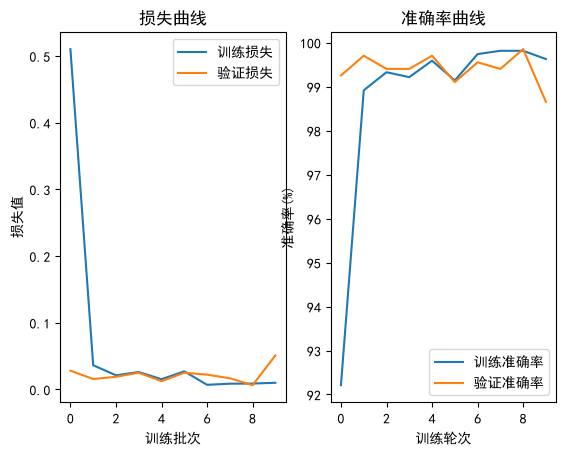

In [40]:
#绘制训练曲线，识别过拟合
#损失曲线
plt.Figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"],label="训练损失")
plt.plot(history["val_loss"],label="验证损失")
plt.xlabel("训练批次")
plt.ylabel("损失值")
plt.title("损失曲线")
plt.legend()

#准确率曲线
plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="训练准确率")
plt.plot(history["val_acc"], label="验证准确率")
plt.xlabel("训练轮次")
plt.ylabel("准确率(%)")
plt.title("准确率曲线")
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01960783576965336..1.0000000076293944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921580076217679..1.0000000236034394].


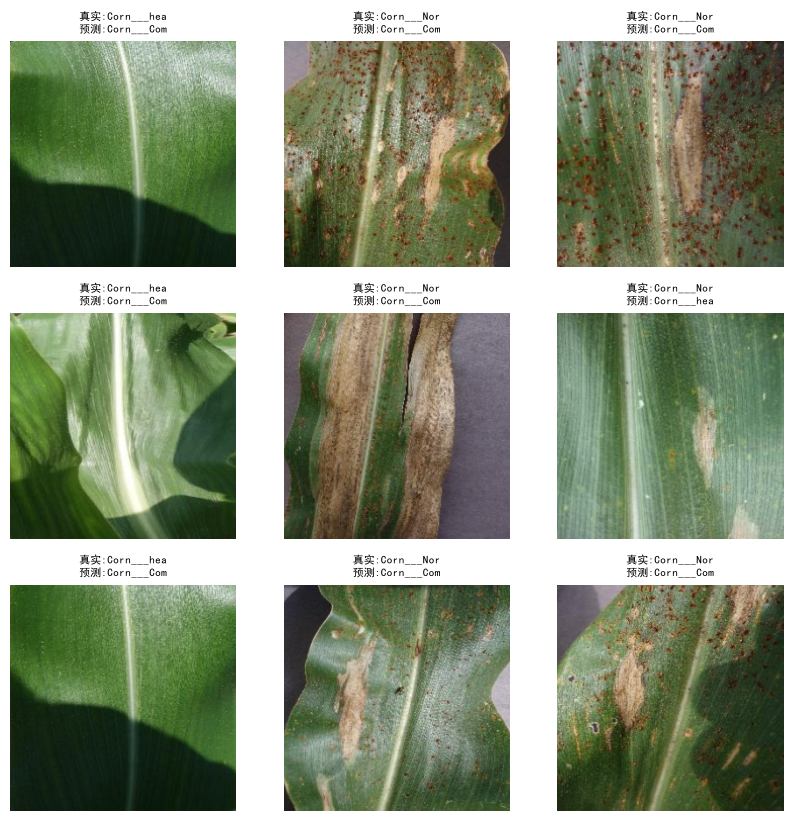

In [41]:
wrong_images = []
wrong_labels = []
wrong_preds = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        # 找出预测错误的图
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i])
                wrong_preds.append(predicted[i])
        if len(wrong_images) >= 9:
            break

# 拼成3×3网格显示
plt.figure(figsize=(10,10))
class_names = full_dataset.classes
# 取实际错误数和9之间的最小值，不会越界
show_count = min(9, len(wrong_images))
for i in range(show_count):
    plt.subplot(3,3,i+1)
    img = wrong_images[i].permute(1,2,0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    plt.imshow(img)
    plt.title(f"真实:{class_names[wrong_labels[i]][:10]}\n预测:{class_names[wrong_preds[i]][:10]}", fontsize=8)
    plt.axis('off')
plt.show()


In [42]:
torch.save(model.state_dict(), "corn_disease_cnn.pth")